In [88]:
!pip install numpy matplotlib utm ultralytics pandas filterpy

In [89]:
!pip install ultralytics filterpy scipy pandas matplotlib tqdm
!pip install opencv-python-headless

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
import sys
sys.path.append('/content/drive/MyDrive/PR2')

import config
import data_loader
import detection
import sort_tracker
import visualization


In [92]:
# Configuration et imports
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# Ajouter le dossier courant au path
sys.path.append('.')

# Import de nos modules personnalisés
import config
import data_loader
from detection import YOLODetector
from sort_tracker import Sort, EnhancedSort
import visualization as vis

print("✅ Modules importés avec succès")
print(f"✅ Dossier des images: {config.DATA_PATH}")
print(f"✅ Modèle YOLO: {config.MODEL_PATH}")
print(f"✅ Dossier de sortie: {config.OUTPUT_DIR}")

# Afficher la configuration
config.print_config()
config.check_paths()

✅ Modules importés avec succès
✅ Dossier des images: /content/drive/MyDrive/PR2/ПР2_data
✅ Modèle YOLO: /content/drive/MyDrive/PR2/mega_hodov2.pt
✅ Dossier de sortie: /content/drive/MyDrive/PR2/output
CONFIGURATION DU PROJET
Dossier de base: /content/drive/MyDrive/PR2
Dossier images: /content/drive/MyDrive/PR2/ПР2_data
Modèle YOLO: /content/drive/MyDrive/PR2/mega_hodov2.pt
Dossier sortie: /content/drive/MyDrive/PR2/output
----------------------------------------
PARAMÈTRES:
  Classe cible: 4 (букса)
  Seuil confiance YOLO: 0.5
  max_age: 5
  min_hits: 3
  iou_threshold: 0.3
  Limite frames: Toutes
✓ Dossier images trouvé avec 207 images
✓ Modèle YOLO trouvé: mega_hodov2.pt


True

In [93]:
# Chargement et analyse des images
print("="*60)
print("CHARGEMENT DES DONNÉES")
print("="*60)

# Récupérer la liste des images
image_files = data_loader.get_image_files()
print(f"\n📸 Nombre total d'images: {len(image_files)}")

if len(image_files) > 0:
    print(f"📸 Première image: {image_files[0]}")
    print(f"📸 Dernière image: {image_files[-1]}")

    # Extraire les numéros de frame
    frame_numbers = data_loader.get_frame_numbers(image_files)
    print(f"📸 Frames: de {min(frame_numbers)} à {max(frame_numbers)}")

    # Statistiques des images
    stats = data_loader.get_image_stats(image_files)
    print(f"\n📊 Statistiques:")
    for k, v in stats.items():
        print(f"   {k}: {v}")

CHARGEMENT DES DONNÉES
📸 207 images trouvées dans /content/drive/MyDrive/PR2/ПР2_data
   Première: rgb_175.png (frame 175)
   Dernière: rgb_381.png (frame 381)

📸 Nombre total d'images: 207
📸 Première image: rgb_175.png
📸 Dernière image: rgb_381.png
📸 Frames: de 175 à 381

📊 Statistiques:
   count: 207
   height_mean: 1240.0
   height_std: 0.0
   width_mean: 1240.0
   width_std: 0.0
   channels: 3
   first_frame: 175
   last_frame: 381
   avg_file_size_kb: 2284.87470703125


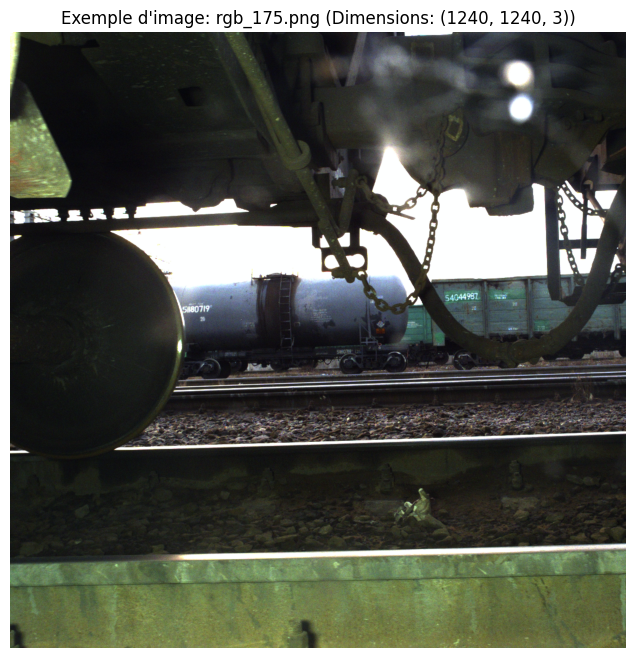

✅ Image chargée avec succès
   Dimensions: (1240, 1240, 3)
   Type: uint8
   Min/Max: 0/255


In [94]:
# Afficher un exemple d'image
if len(image_files) > 0:
    img = data_loader.load_image(image_files[0])

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(f"Exemple d'image: {image_files[0]} (Dimensions: {img.shape})")
    plt.axis('off')
    plt.show()

    print(f"✅ Image chargée avec succès")
    print(f"   Dimensions: {img.shape}")
    print(f"   Type: {img.dtype}")
    print(f"   Min/Max: {img.min()}/{img.max()}")

In [95]:
# Initialiser le détecteur YOLO
print("="*60)
print("INITIALISATION DU DÉTECTEUR YOLO")
print("="*60)

detector = YOLODetector()

print(f"\n✅ Détecteur prêt")
print(f"   Classe cible: {detector.class_id}")
print(f"   Seuil de confiance: {detector.conf_threshold}")
print(f"   Device: {detector.device}")

INITIALISATION DU DÉTECTEUR YOLO
🔄 Chargement du modèle YOLO depuis /content/drive/MyDrive/PR2/mega_hodov2.pt...
   Device: cpu
   Classe cible: 4
   Seuil de confiance: 0.5
✓ Modèle chargé en 0.34 secondes

✅ Détecteur prêt
   Classe cible: 4
   Seuil de confiance: 0.5
   Device: cpu


In [97]:
# Visualisation des détections sur TOUTES les images
print("="*60)
print("VISUALISATION DES DÉTECTIONS SUR TOUTES LES IMAGES")
print("="*60)

total_images = len(image_files)
images_avec_detections = 0
total_detections = 0

for i, img_file in enumerate(image_files):
    # Afficher la progression
    if i % 50 == 0:
        print(f"Progression: {i}/{total_images} images")

    # Charger l'image et faire la détection
    img = data_loader.load_image(img_file)
    detections = detector.detect(img)

    total_detections += len(detections)

    # Afficher l'image si des objets sont détectés
    if len(detections) > 0:
        images_avec_detections += 1

        print(f"\n{'='*50}")
        print(f"Image {i}: {img_file}")
        print(f"   Détections trouvées: {len(detections)}")
        print(f"   Confiance moyenne: {np.mean(detections[:, 4]):.3f}")

        # Afficher les détails de chaque détection
        for j, det in enumerate(detections):
            x1, y1, x2, y2, conf = det
            print(f"   Détection {j+1}: [{(x1):.0f}, {(y1):.0f}, {(x2):.0f}, {(x2):.0f}] conf={conf:.3f}")

        # Créer une figure avec l'image et les détections
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Image originale
        #axes[0].imshow(img)
        #axes[0].set_title(f"Originale: {img_file}")
        #axes[0].axis('off')

        # Image avec détections
        from matplotlib.patches import Rectangle
        axes[1].imshow(img)
        for det in detections:
            x1, y1, x2, y2, conf = det
            rect = Rectangle((x1, y1), x2-x1, y2-y1,
                           linewidth=2, edgecolor='red', facecolor='none')
            axes[1].add_patch(rect)
            axes[1].text(x1, y1-5, f'{conf:.2f}', color='red',
                        bbox=dict(facecolor='white', alpha=0.7))
        axes[1].set_title(f"Détections: {len(detections)} objets")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

print("\n" + "="*60)
print("RÉSUMÉ DES DÉTECTIONS")
print("="*60)
print(f"📊 Total images analysées: {total_images}")
print(f"📊 Images avec détections: {images_avec_detections}")
print(f"📊 Images sans détection: {total_images - images_avec_detections}")
print(f"📊 Total détections: {total_detections}")
print(f"📊 Moyenne détections/image: {total_detections/total_images:.2f}")
print(f"📊 Pourcentage d'images avec objets: {images_avec_detections/total_images*100:.1f}%")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Visualiser des exemples de détection
print("="*60)
print("VISUALISATION DES DÉTECTIONS")
print("="*60)

vis.plot_detection_examples(image_files, detector, data_loader, num_examples=4)
print("✅ Exemples de détection sauvegardés")

In [ ]:
# Analyse statistique des détections
print("="*60)
print("ANALYSE STATISTIQUE DES DÉTECTIONS")
print("="*60)

# Analyser sur 50 images
sample_size = min(50, len(image_files))
sample_files = image_files[:sample_size]

detection_counts = []
confidences = []

for img_file in sample_files:
    img = data_loader.load_image(img_file)
    dets = detector.detect(img)
    detection_counts.append(len(dets))

    if len(dets) > 0:
        confidences.extend(dets[:, 4])

print(f"Analyse sur {sample_size} images:")
print(f"   Moyenne de détections/image: {np.mean(detection_counts):.2f}")
print(f"   Écart-type: {np.std(detection_counts):.2f}")
print(f"   Min: {np.min(detection_counts)}")
print(f"   Max: {np.max(detection_counts)}")
print(f"   Images sans détection: {sum(c == 0 for c in detection_counts)}")

if confidences:
    print(f"\nStatistiques de confiance:")
    print(f"   Moyenne: {np.mean(confidences):.3f}")
    print(f"   Écart-type: {np.std(confidences):.3f}")
    print(f"   Min: {np.min(confidences):.3f}")
    print(f"   Max: {np.max(confidences):.3f}")

# Histogramme des détections
plt.figure(figsize=(10, 5))
plt.hist(detection_counts, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Nombre de détections par image')
plt.ylabel('Fréquence')
plt.title('Distribution des détections')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Initialiser le tracker SORT
print("="*60)
print("INITIALISATION DU TRACKER SORT")
print("="*60)

tracker = Sort()

print(f"\n✅ Tracker SORT initialisé")
print(f"   max_age: {tracker.max_age}")
print(f"   min_hits: {tracker.min_hits}")
print(f"   iou_threshold: {tracker.iou_threshold}")

In [ ]:
# Tester le tracker sur une petite séquence
# NOTE: The actual fix for the ValueError is in the external file 'sort_tracker.py'.
# Please follow the instructions in the 'speak' field to manually modify that file.
print("="*60)
print("TEST DU TRACKER SUR PETITE SÉQUENCE")
print("="*60)

test_frames = 20  # Tester sur 20 images
test_tracker = Sort()  # Tracker séparé pour le test

for i, img_file in enumerate(image_files[:test_frames]):
    img = data_loader.load_image(img_file)
    detections = detector.detect(img)
    tracks = test_tracker.update(detections)

    print(f"Frame {i:2d}: {len(detections)} détections → {len(tracks)} tracks")

print(f"\n✅ Objets uniques détectés sur {test_frames} frames: {test_tracker.get_count()}")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12, 6))
plt.plot(df['frame'], df['tracks'], marker='o', linestyle='-', color='skyblue')
plt.title('Nombre de tracks actifs par frame')
plt.xlabel('Numéro de Frame')
plt.ylabel('Nombre de Tracks Actifs')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df['frame'][::5]) # Show x-ticks every 5 frames for readability
plt.tight_layout()
plt.show()

In [ ]:
print("Information sur le DataFrame df:")
display(df.info())

In [ ]:
print("Premières 10 lignes du DataFrame df:")
display(df.head(10))

In [ ]:
file_path = '/content/drive/MyDrive/PR2/sort_tracker.py'

try:
    with open(file_path, 'r') as f:
        lines = f.readlines()
        # Check line 85 for the modification
        target_line_num = 85
        if target_line_num <= len(lines):
            print(f"Line {target_line_num}: {lines[target_line_num-1].strip()}")
            # Optionally, print a few lines around it for context
            for i in range(max(0, target_line_num-3), min(len(lines), target_line_num+2)):
                if i != target_line_num-1: # Don't print target_line_num again
                    print(f"Line {i+1}: {lines[i].strip()}")
        else:
            print(f"File has fewer than {target_line_num} lines.")

    # Further check for the specific string in the file content
    file_content = ''.join(lines)
    if "np.array([cx, cy, s, r]).reshape((4, 1))" in file_content:
        print("\n✅ The modification 'np.array([cx, cy, s, r]).reshape((4, 1))' was found in the file.")
    else:
        print("\n❌ The modification 'np.array([cx, cy, s, r]).reshape((4, 1))' was NOT found in the file.")

except FileNotFoundError:
    print(f"Error: The file {file_path} was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
# Traitement complet de la séquence
print("="*60)
print("TRAITEMENT COMPLET DE LA SÉQUENCE")
print("="*60)

# Réinitialiser le tracker
tracker = Sort()

# Dictionnaires pour stocker les résultats
track_history = defaultdict(list)
frame_data = []
color_map = {}

# Définir le nombre d'images à traiter
# Pour le test, vous pouvez limiter: process_files = image_files[:100]
# Pour tout traiter: process_files = image_files
process_files = image_files  # Toutes les images

total_frames = len(process_files)
print(f"Traitement de {total_frames} images...")

# Essayer d'utiliser tqdm pour la barre de progression
try:
    from tqdm import tqdm
    iterator = tqdm(enumerate(process_files), total=total_frames, desc="Progression")
    use_tqdm = True
except ImportError:
    print("⚠️ tqdm non installé, progression simple")
    iterator = enumerate(process_files)
    use_tqdm = False

# Boucle principale
for i, img_file in iterator:
    # Charger l'image
    img = data_loader.load_image(img_file)

    # Détecter les objets
    detections = detector.detect(img)

    # Mettre à jour le tracker
    tracks = tracker.update(detections)

    # Enregistrer l'historique des positions
    for track in tracks:
        x1, y1, x2, y2, track_id = track
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2
        track_history[int(track_id)].append((i, center_x, center_y))

    # Enregistrer les données de frame
    frame_data.append({
        'frame': i,
        'file': img_file,
        'detections': len(detections),
        'tracks': len(tracks),
        'unique_count': tracker.get_count()
    })

    # Sauvegarder une visualisation toutes les 50 frames
    if i % 50 == 0 and config.SAVE_INTERMEDIATE_FRAMES:
        img_with_tracks, color_map = vis.draw_tracks(img, tracks, color_map)
        vis.save_visualization_frame(img_with_tracks, tracks, i)

print(f"\n✅ Traitement terminé!")
print(f"   Frames traitées: {total_frames}")
print(f"   Objets uniques comptés: {tracker.get_count()}")

In [ ]:
# Afficher les résultats
print("="*60)
print("RÉSULTATS DU TRACKING")
print("="*60)

# Créer un DataFrame
df = pd.DataFrame(frame_data)

print(f"\n📊 RÉSUMÉ GLOBAL:")
print(f"   Objets uniques comptés: {tracker.get_count()}")
print(f"   Tracks créés: {len(track_history)}")
print(f"   Frames traitées: {len(df)}")

print(f"\n📊 STATISTIQUES PAR FRAME:")
print(f"   Moyenne détections/frame: {df['detections'].mean():.2f}")
print(f"   Moyenne tracks actifs/frame: {df['tracks'].mean():.2f}")
print(f"   Max détections: {df['detections'].max()}")
print(f"   Max tracks: {df['tracks'].max()}")
print(f"   Frames sans détection: {(df['detections'] == 0).sum()}")

print(f"\n📊 STATISTIQUES DES TRACKS:")
track_lengths = [len(v) for v in track_history.values()]
if track_lengths:
    print(f"   Durée moyenne: {np.mean(track_lengths):.1f} frames")
    print(f"   Durée max: {np.max(track_lengths)} frames")
    print(f"   Durée min: {np.min(track_lengths)} frames")

# Afficher les premières lignes
print(f"\n📋 Aperçu des données (10 premières frames):")
display(df.head(10))

In [ ]:
# Visualiser les statistiques de tracking
print("="*60)
print("VISUALISATION DES STATISTIQUES")
print("="*60)

# À remplacer par le vrai nombre si connu
GROUND_TRUTH = 42  # À MODIFIER

vis.plot_tracking_statistics(df, track_history, ground_truth=GROUND_TRUTH)
print("✅ Graphiques sauvegardés")

In [ ]:
# Visualiser les trajectoires
print("="*60)
print("VISUALISATION DES TRAJECTOIRES")
print("="*60)

if len(image_files) > 0:
    bg_img = data_loader.load_image(image_files[0])
    vis.plot_trajectories(track_history, bg_img, max_tracks=30)
    print("✅ Trajectoires sauvegardées")

In [ ]:
# Visualiser quelques frames avec leurs tracks
print("="*60)
print("VISUALISATION DE FRAMES AVEC TRACKS")
print("="*60)

def show_tracking_frame(frame_idx):
    """Affiche une frame spécifique avec les tracks"""
    if frame_idx >= len(process_files):
        print(f"Frame {frame_idx} hors limite")
        return

    img_file = process_files[frame_idx]
    img = data_loader.load_image(img_file)

    # Obtenir les détections et tracks pour cette frame
    detections = detector.detect(img)

    # Créer un tracker temporaire pour obtenir les tracks de cette frame
    temp_tracker = Sort()
    for j in range(frame_idx + 1):
        if j <= frame_idx:
            img_j = data_loader.load_image(process_files[j])
            dets_j = detector.detect(img_j)
            tracks_j = temp_tracker.update(dets_j)

    # Dessiner les tracks
    img_with_tracks, _ = vis.draw_tracks(img, tracks_j)

    plt.figure(figsize=(14, 8))
    plt.imshow(img_with_tracks)
    plt.title(f"Frame {frame_idx}: {img_file} - {len(tracks_j)} tracks actifs")
    plt.axis('off')
    plt.show()

    return len(tracks_j)

# Afficher quelques frames clés
positions = [0, len(process_files)//4, len(process_files)//2, 3*len(process_files)//4, -1]
for idx in positions:
    if 0 <= idx < len(process_files):
        n_tracks = show_tracking_frame(idx)
        print(f"Frame {idx}: {n_tracks} tracks actifs\n")

In [ ]:
# Comparaison avec la version améliorée
print("="*60)
print("COMPARAISON AVEC VERSION AMÉLIORÉE")
print("="*60)

# Initialiser les deux trackers
tracker_std = Sort()
tracker_enhanced = EnhancedSort(adaptive_iou=True)

# Tester sur un nombre limité d'images
test_frames = 100  # À ajuster selon la vitesse
print(f"Test sur {test_frames} images...")

for i, img_file in enumerate(image_files[:test_frames]):
    img = data_loader.load_image(img_file)
    detections = detector.detect(img)

    tracker_std.update(detections)
    tracker_enhanced.update(detections)

    if i % 20 == 0:
        print(f"   Progression: {i}/{test_frames}")

print(f"\n📊 RÉSULTATS:")
print(f"   Version standard: {tracker_std.get_count()} objets uniques")
print(f"   Version améliorée: {tracker_enhanced.get_count()} objets uniques")
print(f"   Différence: {tracker_enhanced.get_count() - tracker_std.get_count()}")

# Afficher les statistiques de confiance de la version améliorée
print(f"\n📊 Analyse des confiances (version améliorée):")
conf_stats = tracker_enhanced.get_confidence_stats()
if conf_stats:
    print(f"   Nombre de tracks avec données de confiance: {len(conf_stats)}")

    # Moyenne des confiances par track
    means = [stats['mean'] for stats in conf_stats.values()]
    print(f"   Confiance moyenne globale: {np.mean(means):.3f}")
    print(f"   Écart-type: {np.std(means):.3f}")

In [ ]:
# Visualiser l'analyse des confiances
print("="*60)
print("ANALYSE DÉTAILLÉE DES CONFIANCES")
print("="*60)

if 'tracker_enhanced' in locals():
    vis.plot_confidence_analysis(tracker_enhanced)
    print("✅ Analyse des confiances sauvegardée")

In [ ]:
# Résumé et comparaison
print("="*60)
print("RÉSUMÉ FINAL ET COMPARAISON")
print("="*60)

GROUND_TRUTH = 42  # À MODIFIER avec la vraie valeur

# Calculer les métriques
detected = tracker.get_count()
error = abs(detected - GROUND_TRUTH)
accuracy = (1 - error/GROUND_TRUTH) * 100 if GROUND_TRUTH > 0 else 0

print(f"\n🎯 COMPARAISON AVEC VÉRITÉ TERRAIN:")
print(f"   Notre comptage: {detected}")
print(f"   Vérité terrain: {GROUND_TRUTH}")
print(f"   Erreur absolue: {error}")
print(f"   Précision: {accuracy:.1f}%")

print(f"\n📊 STATISTIQUES GLOBALES:")
print(f"   Frames traitées: {len(df)}")
print(f"   Tracks créés: {len(track_history)}")
print(f"   Détections totales: {df['detections'].sum()}")
print(f"   Tracks cumulés: {df['tracks'].sum()}")

# Afficher le résumé graphique
vis.plot_tracking_summary(tracker, frame_data, GROUND_TRUTH)

In [ ]:
# Sauvegarder tous les résultats
print("="*60)
print("SAUVEGARDE DES RÉSULTATS")
print("="*60)

# Sauvegarder le DataFrame
df.to_csv(config.OUTPUT_DIR / "tracking_data_complete.csv", index=False)
print(f"✅ Données sauvegardées: {config.OUTPUT_DIR}/tracking_data_complete.csv")

# Sauvegarder les IDs uniques
with open(config.OUTPUT_DIR / "unique_objects.txt", "w") as f:
    f.write(f"Nombre d'objets uniques: {tracker.get_count()}\n")
    f.write(f"IDs: {sorted(tracker.unique_objects)}\n")
    f.write(f"\nParamètres utilisés:\n")
    f.write(f"  max_age: {tracker.max_age}\n")
    f.write(f"  min_hits: {tracker.min_hits}\n")
    f.write(f"  iou_threshold: {tracker.iou_threshold}\n")
print(f"✅ IDs sauvegardés: {config.OUTPUT_DIR}/unique_objects.txt")

# Créer un résumé
summary = pd.DataFrame({
    'Métrique': [
        'Objets uniques', 'Tracks créés', 'Frames traitées',
        'Moyenne détections/frame', 'Max détections/frame',
        'Moyenne tracks/frame', 'Max tracks/frame',
        'Durée moyenne des tracks', 'Durée max des tracks'
    ],
    'Valeur': [
        tracker.get_count(),
        len(track_history),
        len(df),
        f"{df['detections'].mean():.2f}",
        df['detections'].max(),
        f"{df['tracks'].mean():.2f}",
        df['tracks'].max(),
        f"{np.mean([len(v) for v in track_history.values()]):.1f}",
        np.max([len(v) for v in track_history.values()])
    ]
})

summary.to_csv(config.OUTPUT_DIR / "summary.csv", index=False)
print(f"✅ Résumé sauvegardé: {config.OUTPUT_DIR}/summary.csv")

display(summary)

In [ ]:
# Créer une vidéo à partir des frames sauvegardées
print("="*60)
print("CRÉATION DE LA VIDÉO")
print("="*60)

if config.SAVE_INTERMEDIATE_FRAMES:
    vis.create_video_from_frames(fps=10)
    print(f"✅ Vidéo créée: {config.OUTPUT_DIR}/tracking_video.mp4")
else:
    print("⚠️ Les frames intermédiaires n'ont pas été sauvegardées")
    print("   Pour créer une vidéo, mettez SAVE_INTERMEDIATE_FRAMES = True dans config.py")

In [ ]:
# Test de différents paramètres (optionnel, peut être long)
print("="*60)
print("TEST DE DIFFÉRENTS PARAMÈTRES")
print("="*60)

def test_parameters(max_age_list, min_hits_list, iou_list, test_frames=50):
    """Teste différentes combinaisons de paramètres"""
    results = []

    for max_age in max_age_list:
        for min_hits in min_hits_list:
            for iou in iou_list:
                # Créer un tracker avec ces paramètres
                t = Sort(max_age=max_age, min_hits=min_hits, iou_threshold=iou)

                # Tester sur les premières images
                for img_file in image_files[:test_frames]:
                    img = data_loader.load_image(img_file)
                    dets = detector.detect(img)
                    t.update(dets)

                results.append({
                    'max_age': max_age,
                    'min_hits': min_hits,
                    'iou': iou,
                    'unique_count': t.get_count()
                })

                print(f"   Testé: max_age={max_age}, min_hits={min_hits}, iou={iou} → {t.get_count()} objets")

    return pd.DataFrame(results)

# Décommenter pour exécuter (peut être long)
# print("\nTest des paramètres (cela peut prendre quelques minutes)...")
# param_results = test_parameters([3, 5, 7], [2, 3, 4], [0.2, 0.3, 0.4], test_frames=30)
# display(param_results)

# Afficher les meilleurs paramètres
# best = param_results.loc[param_results['unique_count'].idxmax()]
# print(f"\n🏆 Meilleurs paramètres: max_age={best['max_age']}, min_hits={best['min_hits']}, iou={best['iou']}")
# print(f"   → {best['unique_count']} objets")

In [ ]:
# Vérification finale
print("="*60)
print("VÉRIFICATION FINALE")
print("="*60)

print(f"\n✅ Toutes les cellules ont été exécutées avec succès")
print(f"✅ Résultats sauvegardés dans: {config.OUTPUT_DIR}")
print(f"✅ Nombre total d'objets comptés: {tracker.get_count()}")
print(f"✅ Fichiers générés:")

for file in config.OUTPUT_DIR.glob("*"):
    if file.is_file():
        size_kb = file.stat().st_size / 1024
        print(f"   - {file.name} ({size_kb:.1f} KB)")

print("\n" + "="*60)
print("FIN DU RAPPORT")
print("="*60)